<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:128: SyntaxWarning: invalid escape sequence '\d'
<>:79: SyntaxWarning: invalid escape sequence '\d'
<>:128: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3392/1049553707.py:79: SyntaxWarning: invalid escape sequence '\d'
  label=f'Stochastic Threshold $\delta^* \\approx {delta_star:.2f}$',
/tmp/ipykernel_3392/1049553707.py:128: SyntaxWarning: invalid escape sequence '\d'
  f'Probabilistic\nTransition Region\n$\delta^* \\approx {delta_star:.2f}$',


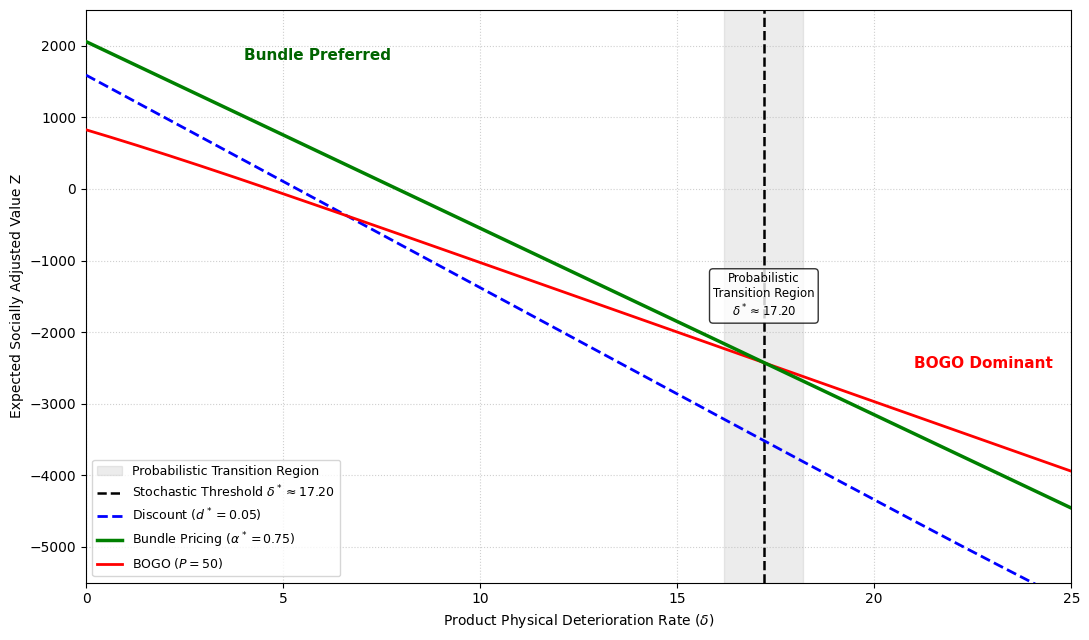

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


a, b, t, P, C, Cw, lmbda, Q = 200, 1.0, 3, 100, 40, 2, 2, 200
sigma = 20

P_discount, P_bundle, P_bogo = 95, 75, 50
theta_discount, theta_bundle, theta_bogo = 0.00, 0.10, 0.20

np.random.seed(42)
epsilon = np.random.normal(0, sigma, 10000)


def run_monte_carlo_delta(delta_val):
  results = {}


  D0_disc = a - b * P_discount - delta_val * t
  D_stoch_disc = np.maximum((1 + theta_discount) * D0_disc + epsilon, 0)
  Y_disc = np.minimum(Q, D_stoch_disc)
  Z_disc = P_discount * Y_disc - C * Q - (Cw + lmbda) * (Q - Y_disc)
  results['Discount'] = np.mean(Z_disc)


  D0_bund = a - b * P_bundle - delta_val * t
  D_stoch_bund = np.maximum((1 + theta_bundle) * D0_bund + epsilon, 0)
  Y_bund = np.minimum(Q, D_stoch_bund)
  Z_bund = P_bundle * Y_bund - C * Q - (Cw + lmbda) * (Q - Y_bund)
  results['Bundle'] = np.mean(Z_bund)


  D0_bogo = a - b * P_bogo - delta_val * t
  D_stoch_bogo = np.maximum((1 + theta_bogo) * D0_bogo + epsilon, 0)
  Y_bogo = np.minimum(Q, D_stoch_bogo)
  Z_bogo = P_bogo * Y_bogo - C * Q - (Cw + lmbda) * (Q - Y_bogo)
  results['BOGO'] = np.mean(Z_bogo)

  return results



delta_range = np.linspace(0, 25, 251)
plot_data = {'delta': [], 'Discount': [], 'Bundle': [], 'BOGO': []}

for d_v in delta_range:
  res = run_monte_carlo_delta(d_v)
  plot_data['delta'].append(d_v)
  plot_data['Discount'].append(res['Discount'])
  plot_data['Bundle'].append(res['Bundle'])
  plot_data['BOGO'].append(res['BOGO'])

df_plot = pd.DataFrame(plot_data)


df_plot['diff_bund_bogo'] = (df_plot['Bundle'] - df_plot['BOGO']).abs()
idx_star = df_plot['diff_bund_bogo'].idxmin()
delta_star = df_plot.loc[idx_star, 'delta']
z_star = df_plot.loc[idx_star, 'Bundle']


plt.figure(figsize=(11, 6.5))

plt.axvspan(
    delta_star - 1.0,
    delta_star + 1.0,
    color='gray',
    alpha=0.15,
    zorder=1,
    label='Probabilistic Transition Region',
)
plt.axvline(
    x=delta_star,
    color='black',
    linestyle='--',
    linewidth=1.8,
    zorder=3,
    label=f'Stochastic Threshold $\delta^* \\approx {delta_star:.2f}$',
)

plt.plot(
    df_plot['delta'],
    df_plot['Discount'],
    label=r'Discount ($d^*=0.05$)',
    color='blue',
    linestyle='--',
    linewidth=2,
    zorder=4,
)
plt.plot(
    df_plot['delta'],
    df_plot['Bundle'],
    label=r'Bundle Pricing ($\alpha^*=0.75$)',
    color='green',
    linewidth=2.5,
    zorder=5,
)
plt.plot(
    df_plot['delta'],
    df_plot['BOGO'],
    label=r'BOGO ($P=50$)',
    color='red',
    linewidth=2,
    zorder=4,
)

plt.text(
    4.0,
    1800,
    'Bundle Preferred',
    fontsize=11,
    fontweight='bold',
    color='darkgreen',
)
plt.text(
    21.0,
    -2500,
    'BOGO Dominant',
    fontsize=11,
    fontweight='bold',
    color='red',
)

plt.text(
    delta_star,
    z_star + 600,
    f'Probabilistic\nTransition Region\n$\delta^* \\approx {delta_star:.2f}$',
    fontsize=8.5,
    ha='center',
    va='bottom',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
)


plt.xlabel(r'Product Physical Deterioration Rate ($\delta$)', fontsize=10)
plt.ylabel('Expected Socially Adjusted Value Z', fontsize=10)
plt.xlim(0, 25)
plt.ylim(-5500, 2500)
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()